In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df = pd.read_csv('/content/kidney_disease_dataset.csv')

In [3]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48,80,1.020,1,0,0,1,0,0,7800,...,44,7800,0,1,1,1,0,0,0,1
1,7,50,1.020,4,0,0,1,0,0,6000,...,38,6000,0,0,0,0,0,0,0,0
2,62,80,1.010,2,3,1,1,0,0,7500,...,31,7500,0,1,1,1,1,0,0,1
3,48,70,1.005,4,0,1,1,0,0,6700,...,32,6700,0,0,0,0,1,0,0,0
4,51,80,1.010,2,0,1,1,0,0,7300,...,35,7300,0,0,0,0,0,0,0,0


In [4]:
df=df.drop(['age', 'bp','sg', 'al','su','rbc','pc',	'pcc','ba','bu','sc','sod','pot','hemo','pcv','rc','appet','pe','ane'], axis=1)

In [5]:
df.head()

,bgr,wc,htn,dm,cad,classification
0,7800,7800,1,1,1,1
1,6000,6000,0,0,0,0
2,7500,7500,1,1,1,1
3,6700,6700,0,0,0,0
4,7300,7300,0,0,0,0


In [6]:
# Assume 'classification' is the target
X = df.drop('classification', axis=1)
y = df['classification']

# If there are categorical columns, encode them first
X = pd.get_dummies(X, drop_first=True)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion='gini',splitter='best',max_depth=None,min_samples_split=2,min_samples_leaf=1,min_weight_fraction_leaf=0.0,max_features=None,random_state=42,max_leaf_nodes=None,min_impurity_decrease=0.0,class_weight=None,ccp_alpha=0.0,monotonic_cst=None)
classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [8]:
y_pred = classifier.predict(X_test)

In [9]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        38
           2       1.00      1.00      1.00         1

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



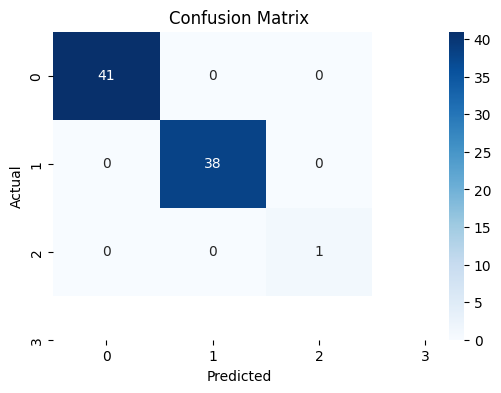

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

report = classification_report(y_test, y_pred)
print("Classification Report:\n")
print(report)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [11]:
from sklearn.svm import SVC
classifier = SVC(C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True,
            probability=True, tol=0.001, cache_size=200, class_weight=None, verbose=False,
            max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=0)
classifier.fit(X_train, y_train)

SVC(probability=True, random_state=0)

In [12]:
y_pred = classifier.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        38
           2       1.00      1.00      1.00         1

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



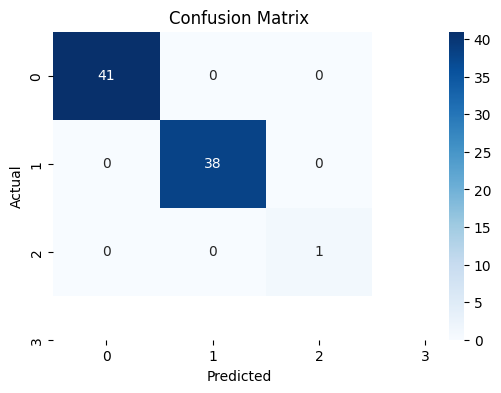

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

report = classification_report(y_test, y_pred)
print("Classification Report:\n")
print(report)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
clf = RandomForestClassifier(max_depth=2, random_state=0)
clf.fit(X, y)

RandomForestClassifier(max_depth=2, random_state=0)

In [21]:
y_pred = classifier.predict(X_test)

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00        38
           2       1.00      1.00      1.00         1

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



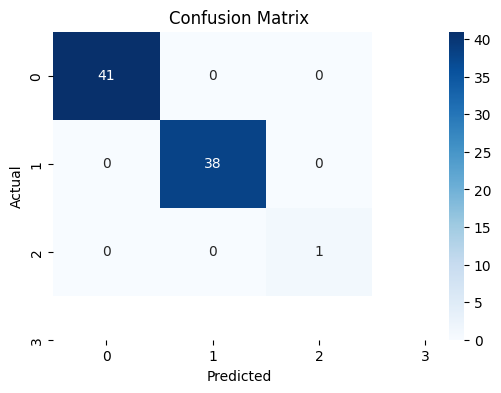

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

report = classification_report(y_test, y_pred)
print("Classification Report:\n")
print(report)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classifier.classes_, yticklabels=classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()